# K-Means Cluster Diagnostics

In this notebook we evaluate clustering quality using:

• Elbow Method  
• Silhouette Score  

These techniques help determine the optimal number of clusters.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

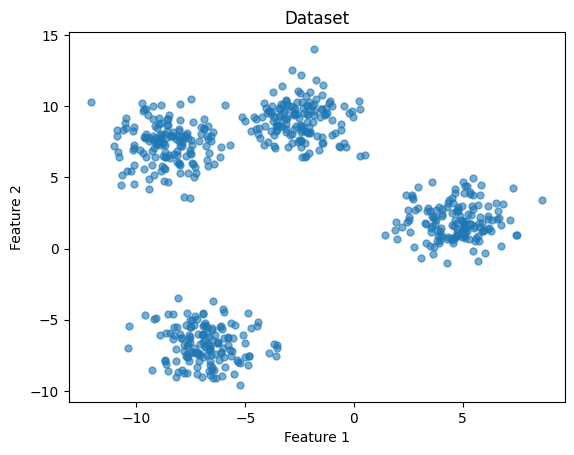

In [2]:
X, y = make_blobs(
    n_samples=600,
    centers=4,
    cluster_std=1.3,
    random_state=42
)

plt.scatter(X[:, 0], X[:, 1], s =25, alpha=0.6)
plt.title("Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## Dataset

We generate synthetic data with four natural clusters.

Since we already know the true number of clusters is 4,
this dataset is useful for testing cluster diagnostics.

In [3]:
k_values = range(1, 11)
wcss = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

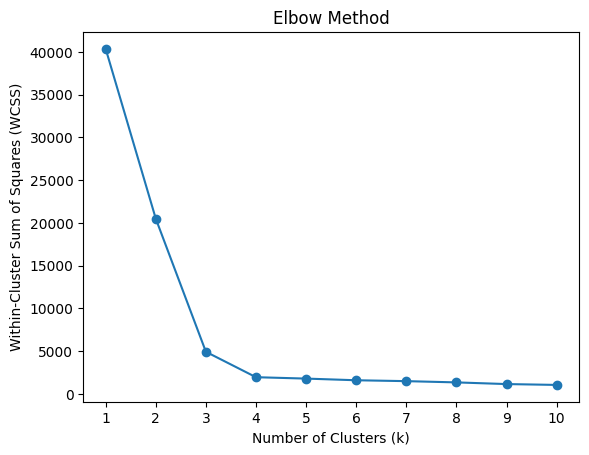

In [5]:
plt.plot(k_values, wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.xticks(k_values)
plt.show()

## Elbow Method Interpretation

As the number of clusters increases, WCSS decreases.

However, after a certain point the improvement becomes small.

The optimal number of clusters is typically chosen at the
**elbow point**, where adding more clusters gives diminishing returns.

In [6]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)

    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

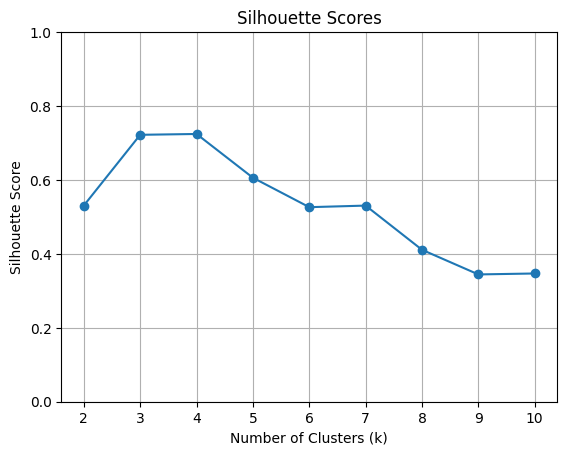

In [11]:
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title("Silhouette Scores")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 11))
plt.ylim(0, 1)
plt.grid()
plt.show()

## Silhouette Score Interpretation

Silhouette score measures how well each point fits its cluster.

Score Range:

1 → perfect clustering  
0 → clusters overlap  
< 0 → points likely misclassified

The best number of clusters corresponds to the **highest silhouette score**.

## Key Takeaways

• Elbow Method evaluates cluster compactness using WCSS.

• Silhouette Score evaluates both cluster cohesion and separation.

• Using both diagnostics together provides a more reliable estimate
  of the optimal number of clusters.

• In this dataset both methods correctly suggest k = 4.

In [13]:
silhouette_scores

[0.5307637381443135,
 0.7221805831176541,
 0.7244182698344959,
 0.6060018502243067,
 0.5263858802137552,
 0.530645609819177,
 0.41106223980672263,
 0.344398099361106,
 0.34697062205857643]